# LinkedIn Professional Profiles - Exploratory Data Analysis
## Comprehensive Analysis for Wide&Deep Recommender System

**Dataset:** 1,000 LinkedIn Professional Profiles  
**Purpose:** Understand profile structure, extract features for simulation recommendations  
**Output:** Feature selection for Wide&Deep training

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
import ast
from collections import Counter
import re

warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

# Paths
data_path = Path('/workspace/data/processed/linkedin/people_profiles_datasets.csv')
viz_dir = Path('/workspace/data/visualizations/linkedin')
output_dir = Path('/workspace/data/processed/linkedin')
viz_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")

✓ Setup complete


In [2]:
# ==============================================================================
# HELPER FUNCTIONS FOR SAFE PLOTTING
# ==============================================================================

def safe_plot_horizontal_bar(ax, counter, top_n, title, color):
    """
    Safely plot horizontal bar chart from Counter object.
    Handles empty data gracefully.
    
    Args:
        ax: matplotlib axis
        counter: Counter object
        top_n: number of top items to show
        title: plot title
        color: bar color
    """
    if len(counter) > 0:
        try:
            data = pd.Series(dict(counter.most_common(top_n)))
            if len(data) > 0 and data.sum() > 0:
                data.plot(kind='barh', ax=ax, color=color)
                ax.set_xlabel('Count')
                ax.set_title(title)
                ax.invert_yaxis()
                return True
        except Exception as e:
            print(f"Warning: Could not plot {title}: {e}")
    
    # If no data or error, show message
    ax.text(0.5, 0.5, f'No data available\n({len(counter)} records found)', 
            ha='center', va='center', transform=ax.transAxes, fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    return False


def safe_plot_vertical_bar(ax, counter, top_n, title, color):
    """
    Safely plot vertical bar chart from Counter object.
    """
    if len(counter) > 0:
        try:
            data = pd.Series(dict(counter.most_common(top_n)))
            if len(data) > 0 and data.sum() > 0:
                data.plot(kind='bar', ax=ax, color=color)
                ax.set_ylabel('Count')
                ax.set_title(title)
                ax.tick_params(axis='x', rotation=45)
                return True
        except Exception as e:
            print(f"Warning: Could not plot {title}: {e}")
    
    ax.text(0.5, 0.5, f'No data available', 
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title(title)
    ax.axis('off')
    return False


def safe_plot_pie(ax, data_dict, title):
    """
    Safely plot pie chart.
    """
    if data_dict and sum(data_dict.values()) > 0:
        try:
            data = pd.Series(data_dict)
            data.plot(kind='pie', ax=ax, autopct='%1.1f%%', 
                     startangle=90, colors=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'])
            ax.set_title(title)
            ax.set_ylabel('')
            return True
        except Exception as e:
            print(f"Warning: Could not plot {title}: {e}")
    
    ax.text(0.5, 0.5, 'No data available', 
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title(title)
    ax.axis('off')
    return False


def safe_plot_histogram(ax, data, bins, title, color, xlabel='Value'):
    """
    Safely plot histogram.
    """
    if len(data) > 0 and data.notna().sum() > 0:
        try:
            clean_data = data.dropna()
            ax.hist(clean_data, bins=bins, color=color, edgecolor='black')
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Frequency')
            ax.set_title(title)
            ax.axvline(clean_data.mean(), color='red', linestyle='--', 
                      label=f'Mean: {clean_data.mean():.1f}')
            ax.legend()
            return True
        except Exception as e:
            print(f"Warning: Could not plot {title}: {e}")
    
    ax.text(0.5, 0.5, 'No data available', 
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title(title)
    ax.axis('off')
    return False


print("✓ Safe plotting functions loaded")

✓ Safe plotting functions loaded


---
## Step 1: Load Data & Schema Analysis

In [3]:
# Load dataset
df = pd.read_csv(data_path, low_memory=False)

print("Dataset Shape:")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

print("\n" + "="*80)
print("COLUMN NAMES")
print("="*80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "="*80)
print("DATA TYPES")
print("="*80)
display(df.dtypes.to_frame('dtype'))

print("\n" + "="*80)
print("SAMPLE RECORDS")
print("="*80)
display(df.head(3))

Dataset Shape:
  Rows: 1,000
  Columns: 26

COLUMN NAMES
 1. timestamp
 2. id
 3. name
 4. city
 5. country_code
 6. region
 7. current_company:company_id
 8. current_company:name
 9. position
10. following
11. about
12. posts
13. groups
14. current_company
15. experience
16. url
17. people_also_viewed
18. educations_details
19. education
20. avatar
21. languages
22. certifications
23. recommendations
24. recommendations_count
25. volunteer_experience
26. сourses

DATA TYPES


,dtype
timestamp,object
id,object
name,object
city,object
country_code,object
region,object
current_company:company_id,object
current_company:name,object
position,object
following,float64



SAMPLE RECORDS


,timestamp,id,name,city,country_code,region,current_company:company_id,current_company:name,position,following,...,people_also_viewed,educations_details,education,avatar,languages,certifications,recommendations,recommendations_count,volunteer_experience,сourses
0,2023-01-10,catherinemcilkenny,"Catherine Fitzpatrick (McIlkenny), B.A",Canada,CA,NaN,NaN,NaN,Snr Business Analyst at Emploi et Développemen...,NaN,...,"[{""profile_link"":""https://ca.linkedin.com/in/l...",Queen's University Belfast,"[{""degree"":""Bachelor of Arts (B.A.) Honours"",""...",https://media.licdn.com/dms/image/C4E03AQEcz_j...,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-12-17,margot-bon-51a04624,Margot Bon,"The Randstad, Netherlands",NL,EU,gemeente-utrecht,Gemeente Utrecht,Communicatieadviseur Corporate & Strategie Gem...,NaN,...,"[{""profile_link"":""https://nl.linkedin.com/in/j...",NaN,"[{""degree"":""Scrum en Agile werken"",""end_year"":...",https://static.licdn.com/sc/h/244xhbkr7g40x6bs...,"[{""subtitle"":""Professional working proficiency...","[{""meta"":""Issued Jun 2013"",""subtitle"":""Van der...",Menno H. Poort “Ik werk al jaren prettig met M...,2.0,"[{""cause"":"""",""duration"":""Sep 2010 Jul 2020 9 y...",NaN
2,2023-05-17,mike-dean-8509a193,Mike Dean,"England, United Kingdom",UK,NaN,network-rail,Network Rail,Network Data Manager at Network Rail,NaN,...,"[{""profile_link"":""https://uk.linkedin.com/in/g...",Brighton Polytechnic,"[{""degree"":""2:2"",""end_year"":""1991"",""field"":""El...",https://media.licdn.com/dms/image/C4D03AQHLj-Z...,NaN,NaN,NaN,NaN,NaN,NaN


---
## Step 2: Missing Values Analysis

Missing Values Summary:
Total cells: 26,000
Missing cells: 9,855
Missing percentage: 37.90%

COLUMNS WITH MISSING VALUES (> 0%)


,Column,Missing_Count,Missing_Percent,Dtype
сourses,сourses,993,99.3,object
groups,groups,890,89.0,object
volunteer_experience,volunteer_experience,884,88.4,object
recommendations,recommendations,827,82.7,object
recommendations_count,recommendations_count,827,82.7,float64
certifications,certifications,816,81.6,object
languages,languages,745,74.5,object
posts,posts,583,58.3,object
region,region,544,54.4,object
following,following,519,51.9,float64


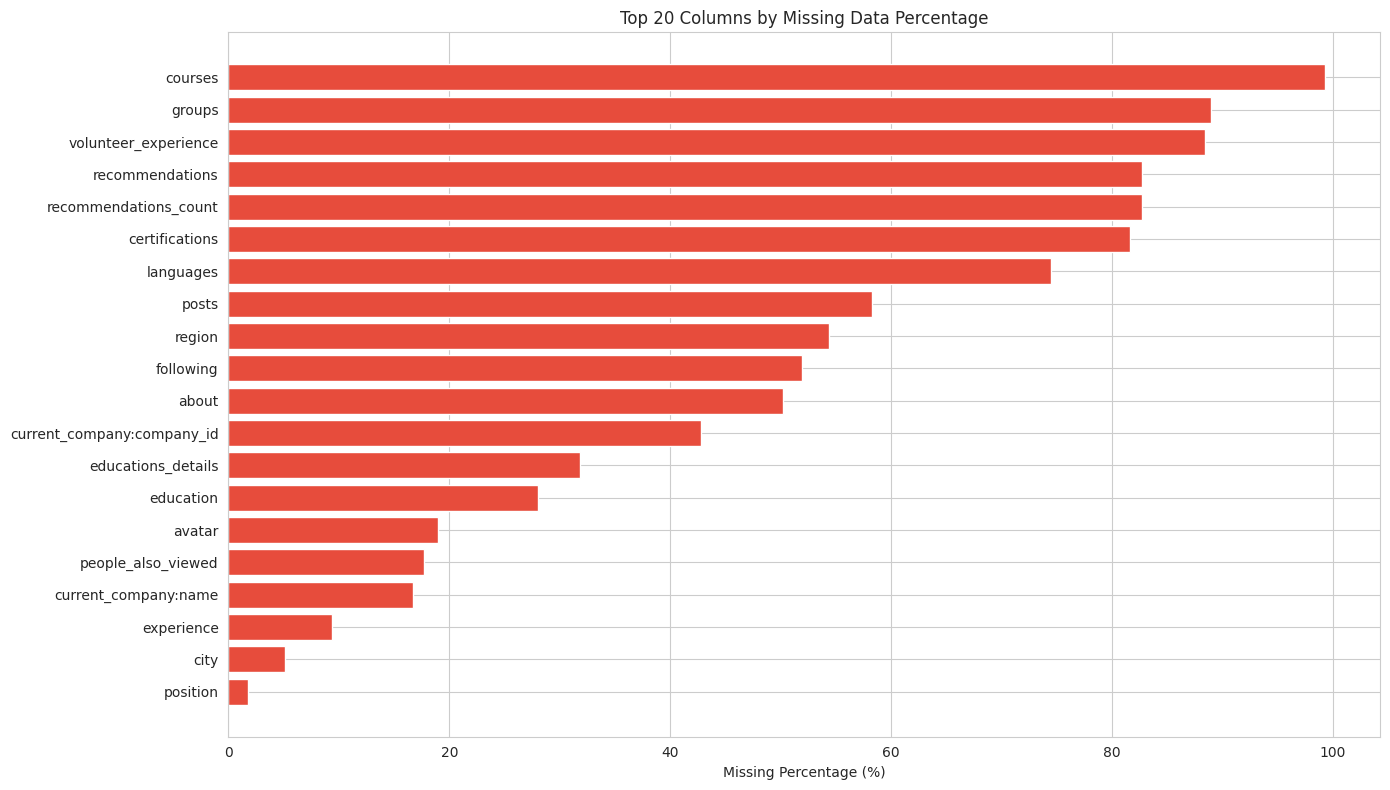


✓ Missing values analysis complete


In [4]:
# Calculate missing values
missing_analysis = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype': df.dtypes
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(f"Total cells: {df.shape[0] * df.shape[1]:,}")
print(f"Missing cells: {df.isnull().sum().sum():,}")
print(f"Missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

print("\n" + "="*80)
print("COLUMNS WITH MISSING VALUES (> 0%)")
print("="*80)
display(missing_analysis[missing_analysis['Missing_Count'] > 0])

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
top_missing = missing_analysis.nlargest(20, 'Missing_Percent')
ax.barh(top_missing['Column'], top_missing['Missing_Percent'], color='#e74c3c')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Top 20 Columns by Missing Data Percentage')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(viz_dir / '01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Missing values analysis complete")

---
## Step 3: Basic Profile Statistics

In [5]:
print("BASIC PROFILE STATISTICS")
print("="*80)

# Unique counts
print("\nUnique Values:")
print(f"  Unique IDs: {df['id'].nunique():,}")
print(f"  Unique Names: {df['name'].nunique():,}")
print(f"  Unique Cities: {df['city'].nunique():,}")
print(f"  Unique Countries: {df['country_code'].nunique()}")
print(f"  Unique Regions: {df['region'].nunique()}")
print(f"  Unique Current Companies: {df['current_company:name'].nunique():,}")
print(f"  Unique Positions: {df['position'].nunique():,}")

# Check for duplicates
duplicates = df.duplicated(subset=['id']).sum()
print(f"\nDuplicate IDs: {duplicates}")

# Profile completeness indicators
print("\nProfile Completeness:")
print(f"  Has About Section: {df['about'].notna().sum():,} ({df['about'].notna().mean()*100:.1f}%)")
print(f"  Has Experience: {df['experience'].notna().sum():,} ({df['experience'].notna().mean()*100:.1f}%)")
print(f"  Has Education: {df['education'].notna().sum():,} ({df['education'].notna().mean()*100:.1f}%)")
print(f"  Has Languages: {df['languages'].notna().sum():,} ({df['languages'].notna().mean()*100:.1f}%)")
print(f"  Has Certifications: {df['certifications'].notna().sum():,} ({df['certifications'].notna().mean()*100:.1f}%)")
print(f"  Has Volunteer Experience: {df['volunteer_experience'].notna().sum():,} ({df['volunteer_experience'].notna().mean()*100:.1f}%)")

print("\n✓ Basic statistics complete")

BASIC PROFILE STATISTICS

Unique Values:
  Unique IDs: 1,000
  Unique Names: 1,000
  Unique Cities: 671
  Unique Countries: 82
  Unique Regions: 5
  Unique Current Companies: 813
  Unique Positions: 925

Duplicate IDs: 0

Profile Completeness:
  Has About Section: 498 (49.8%)
  Has Experience: 906 (90.6%)
  Has Education: 720 (72.0%)
  Has Languages: 255 (25.5%)
  Has Certifications: 184 (18.4%)
  Has Volunteer Experience: 116 (11.6%)

✓ Basic statistics complete


---
## Step 4: Geographic Distribution

TOP 20 COUNTRIES
  US   :  356 (35.60%)
  IN   :   63 ( 6.30%)
  GB   :   53 ( 5.30%)
  AU   :   46 ( 4.60%)
  CA   :   34 ( 3.40%)
  DE   :   34 ( 3.40%)
  UK   :   32 ( 3.20%)
  BR   :   32 ( 3.20%)
  NL   :   23 ( 2.30%)
  FR   :   20 ( 2.00%)
  ES   :   18 ( 1.80%)
  SE   :   16 ( 1.60%)
  TR   :   13 ( 1.30%)
  ID   :   12 ( 1.20%)
  CH   :   12 ( 1.20%)
  MX   :   12 ( 1.20%)
  IT   :   11 ( 1.10%)
  EG   :   11 ( 1.10%)
  CO   :   10 ( 1.00%)
  CN   :    9 ( 0.90%)

REGIONS: 5 unique
region
EU    209
AS    144
OC     41
SA     36
AF     26
Name: count, dtype: int64

TOP 20 CITIES:
  United States                           :  16
  London, England, United Kingdom         :  15
  United Kingdom                          :   9
  Mumbai, Maharashtra, India              :   8
  São Paulo, São Paulo, Brazil            :   8
  Germany                                 :   8
  Egypt                                   :   8
  Israel                                  :   7
  Australia          

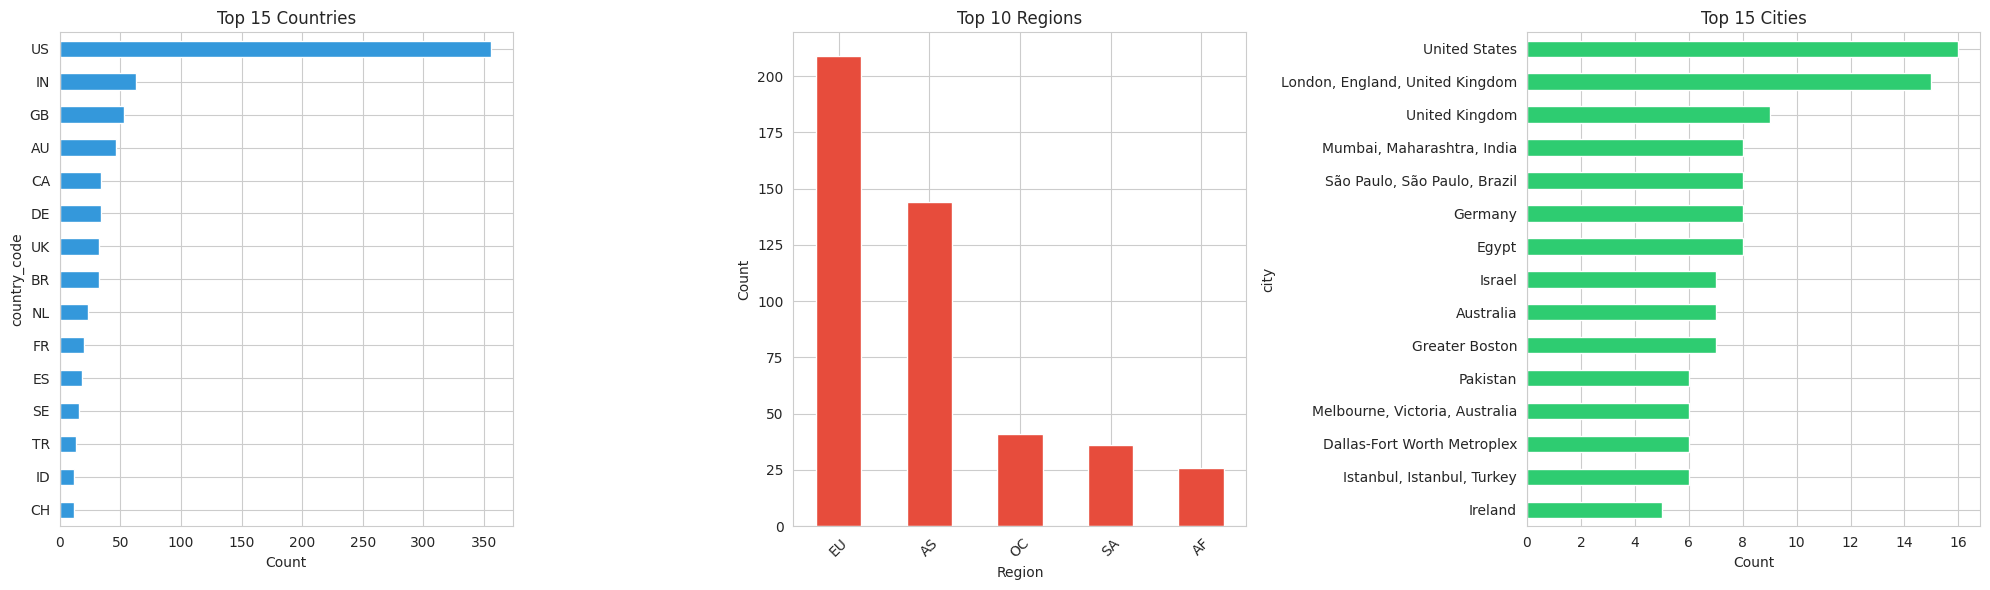


✓ Geographic analysis complete


In [6]:
# Country distribution
country_dist = df['country_code'].value_counts().head(20)

print("TOP 20 COUNTRIES")
print("="*80)
for country, count in country_dist.items():
    print(f"  {country:5s}: {count:4d} ({count/len(df)*100:5.2f}%)")

# Region distribution
region_dist = df['region'].value_counts()
print(f"\nREGIONS: {len(region_dist)} unique")
print(region_dist.head(10))

# City distribution
city_dist = df['city'].value_counts().head(20)
print(f"\nTOP 20 CITIES:")
for city, count in city_dist.items():
    if pd.notna(city):
        print(f"  {city[:40]:40s}: {count:3d}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Country
country_dist.head(15).plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Countries')
axes[0].invert_yaxis()

# Region
region_dist.head(10).plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
axes[1].set_title('Top 10 Regions')
axes[1].tick_params(axis='x', rotation=45)

# City
city_dist.head(15).plot(kind='barh', ax=axes[2], color='#2ecc71')
axes[2].set_xlabel('Count')
axes[2].set_title('Top 15 Cities')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(viz_dir / '02_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Geographic analysis complete")

---
## Step 5: Current Position & Company Analysis

CURRENT POSITIONS

Top 30 Positions:
 1. --                                                                    :  57
 2. Hospital & Health Care Professional                                   :   2
 3. Snr Business Analyst at Emploi et Développement social Canada (EDSC) /:   1
 4. UX/UI Designer at DaisyBill                                           :   1
 5. Product Development Consultant, ALTEN                                 :   1
 6. Business Manager Service and Support på Keysight Technologies         :   1
 7. Global Account Management I Business Development I Design I Sustainabi:   1
 8. Supervisor of Mitigation Department in Jacksonville at Regency DRT    :   1
 9. Senior Supervisor at Financial Conduct Authority                      :   1
10. Marketing Specialist at Genoa Healthcare                              :   1
11. Certified B2C Salesforce Commerce Cloud Fullstack Developer           :   1
12. Academic at Excel Tutoring                                            :   1
13.

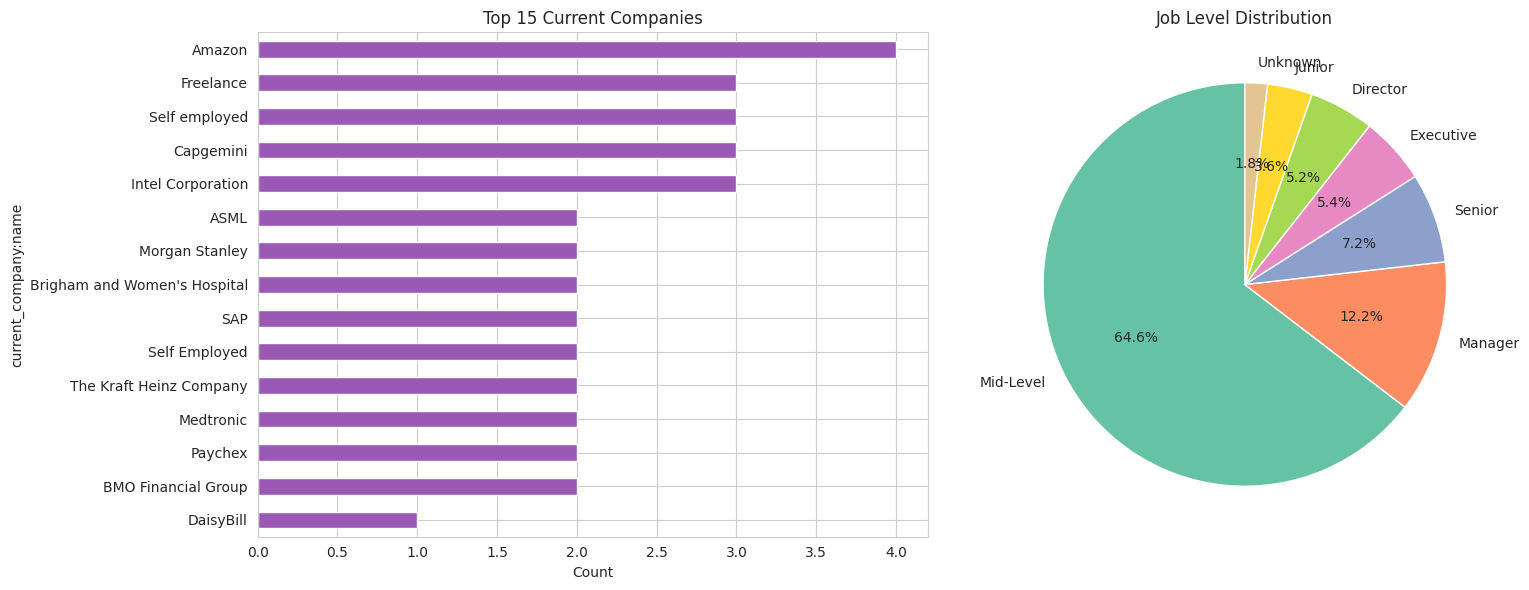


✓ Position and company analysis complete


In [7]:
print("CURRENT POSITIONS")
print("="*80)

# Position analysis
position_dist = df['position'].value_counts().head(30)
print(f"\nTop 30 Positions:")
for i, (pos, count) in enumerate(position_dist.items(), 1):
    if pd.notna(pos):
        print(f"{i:2d}. {pos[:70]:70s}: {count:3d}")

# Company analysis
print("\n" + "="*80)
print("CURRENT COMPANIES")
print("="*80)
company_dist = df['current_company:name'].value_counts().head(20)
print(f"\nTop 20 Companies:")
for i, (company, count) in enumerate(company_dist.items(), 1):
    if pd.notna(company) and company != '':
        print(f"{i:2d}. {company[:50]:50s}: {count:3d}")

# Extract job roles from positions
def extract_job_level(position):
    if pd.isna(position):
        return 'Unknown'
    position_lower = position.lower()
    if any(word in position_lower for word in ['ceo', 'chief', 'president', 'founder', 'owner']):
        return 'Executive'
    elif any(word in position_lower for word in ['director', 'head', 'vp', 'vice president']):
        return 'Director'
    elif any(word in position_lower for word in ['senior', 'sr.', 'lead', 'principal']):
        return 'Senior'
    elif any(word in position_lower for word in ['manager', 'coordinator']):
        return 'Manager'
    elif any(word in position_lower for word in ['junior', 'jr.', 'assistant', 'associate']):
        return 'Junior'
    else:
        return 'Mid-Level'

df['job_level'] = df['position'].apply(extract_job_level)
job_level_dist = df['job_level'].value_counts()

print("\n" + "="*80)
print("JOB LEVEL DISTRIBUTION")
print("="*80)
for level, count in job_level_dist.items():
    print(f"  {level:12s}: {count:4d} ({count/len(df)*100:5.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top companies
company_dist.head(15).plot(kind='barh', ax=axes[0], color='#9b59b6')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Current Companies')
axes[0].invert_yaxis()

# Job levels
job_level_dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Job Level Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(viz_dir / '03_position_company_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Position and company analysis complete")

---
## Step 6: Education Analysis (CRITICAL for Recommender)

EDUCATION ANALYSIS
Total education records parsed: 0
Profiles with education data: 682 (68.2%)

Top 20 Degrees:

TOP 30 FIELDS OF STUDY

TOP 20 SCHOOLS/UNIVERSITIES


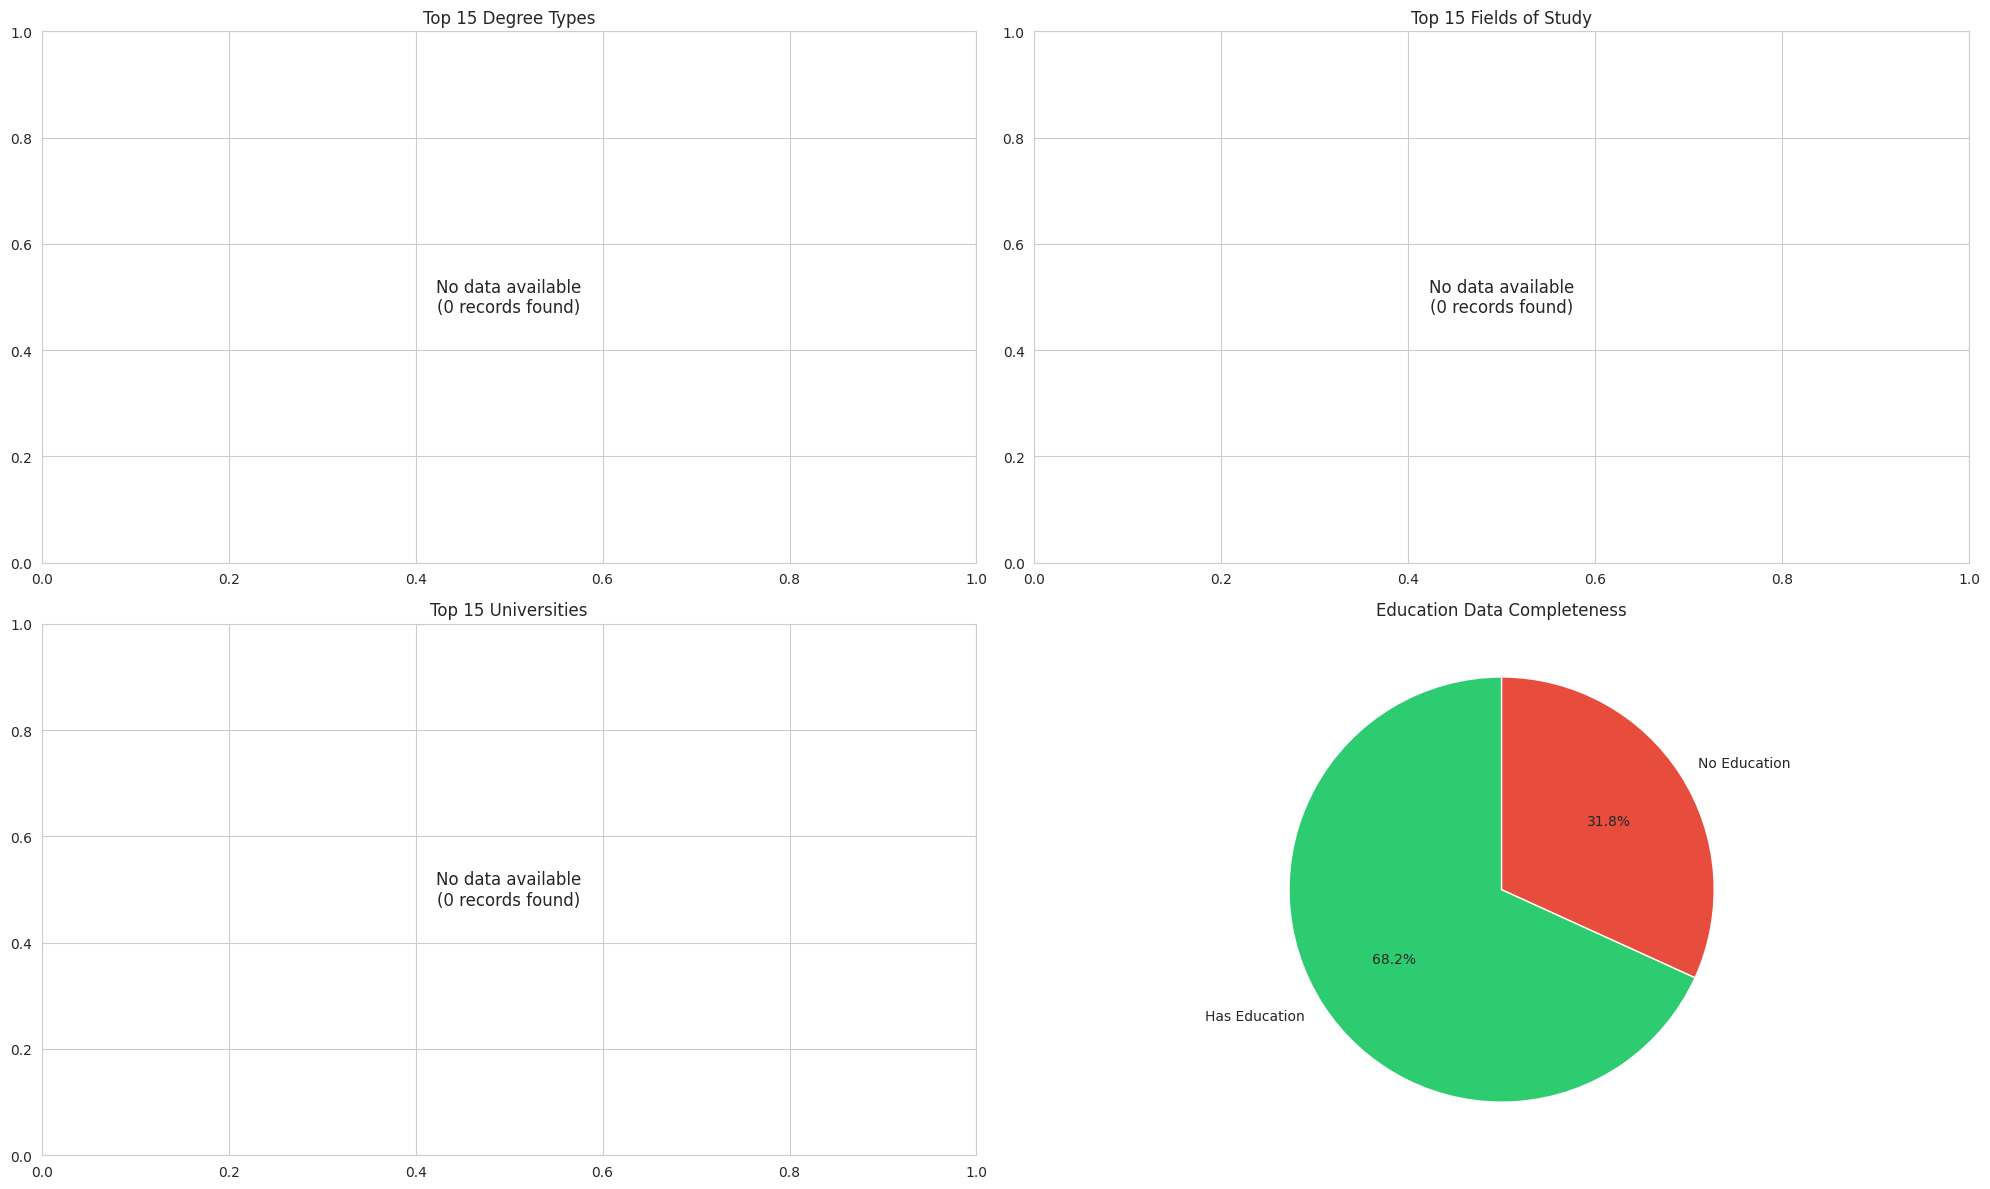


✓ Education analysis complete


In [8]:
print("EDUCATION ANALYSIS")
print("="*80)

# Parse education details (JSON format)
def parse_education(edu_json):
    if pd.isna(edu_json) or edu_json == '[]' or edu_json == '':
        return []
    try:
        edu_list = ast.literal_eval(edu_json)
        return edu_list if isinstance(edu_list, list) else []
    except:
        return []

# Extract all degrees and fields
all_degrees = []
all_fields = []
all_schools = []

for _, row in df.iterrows():
    edu_list = parse_education(row['educations_details'])
    for edu in edu_list:
        if isinstance(edu, dict):
            if 'degree' in edu and edu['degree']:
                all_degrees.append(edu['degree'])
            if 'field' in edu and edu['field']:
                all_fields.append(edu['field'])
            if 'title' in edu and edu['title']:
                all_schools.append(edu['title'])

print(f"Total education records parsed: {len(all_degrees)}")
print(f"Profiles with education data: {df['educations_details'].notna().sum()} ({df['educations_details'].notna().mean()*100:.1f}%)")

# Degree distribution
degree_counts = Counter(all_degrees)
print("\nTop 20 Degrees:")
for i, (degree, count) in enumerate(degree_counts.most_common(20), 1):
    print(f"{i:2d}. {degree[:60]:60s}: {count:3d}")

# Field of study distribution
field_counts = Counter(all_fields)
print("\n" + "="*80)
print("TOP 30 FIELDS OF STUDY")
print("="*80)
for i, (field, count) in enumerate(field_counts.most_common(30), 1):
    print(f"{i:2d}. {field[:60]:60s}: {count:3d}")

# School distribution
school_counts = Counter(all_schools)
print("\n" + "="*80)
print("TOP 20 SCHOOLS/UNIVERSITIES")
print("="*80)
for i, (school, count) in enumerate(school_counts.most_common(20), 1):
    print(f"{i:2d}. {school[:60]:60s}: {count:3d}")

# FIXED STEP 6 VISUALIZATION CODE
# Replace the visualization section (lines 58-76) with this code:

# Visualize (with error handling for empty data)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Helper function to safely plot
def safe_plot_horizontal_bar(ax, counter, top_n, title, color):
    """Safely plot horizontal bar chart from Counter object"""
    if len(counter) > 0:
        data = pd.Series(dict(counter.most_common(top_n)))
        if len(data) > 0 and data.sum() > 0:
            data.plot(kind='barh', ax=ax, color=color)
            ax.set_xlabel('Count')
            ax.set_title(title)
            ax.invert_yaxis()
            return True
    # If no data, show message
    ax.text(0.5, 0.5, f'No data available\n({len(counter)} records found)', 
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    return False

# Plot 1: Top degrees
safe_plot_horizontal_bar(axes[0, 0], degree_counts, 15, 'Top 15 Degree Types', '#3498db')

# Plot 2: Top fields
safe_plot_horizontal_bar(axes[0, 1], field_counts, 15, 'Top 15 Fields of Study', '#e74c3c')

# Plot 3: Top schools
safe_plot_horizontal_bar(axes[1, 0], school_counts, 15, 'Top 15 Universities', '#2ecc71')

# Plot 4: Education completeness (pie chart)
has_edu = int((df['educations_details'].notna() & (df['educations_details'] != '[]')).sum())
no_edu = len(df) - has_edu

if has_edu > 0 or no_edu > 0:
    edu_completeness = pd.Series({
        'Has Education': has_edu,
        'No Education': no_edu
    })
    edu_completeness.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', 
                          startangle=90, colors=['#2ecc71', '#e74c3c'])
    axes[1, 1].set_title('Education Data Completeness')
    axes[1, 1].set_ylabel('')
else:
    axes[1, 1].text(0.5, 0.5, 'No education data', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Education Data Completeness')

plt.tight_layout()
plt.savefig(viz_dir / '04_education_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Education analysis complete")

---
## Step 7: Experience Analysis

EXPERIENCE ANALYSIS
Total experience records parsed: 991
Total job titles extracted: 1170
Profiles with experience data: 906 (90.6%)

Position Count Statistics:
  Mean positions per profile: 1.19
  Median positions: 0
  Max positions: 20

TOP 20 INDUSTRIES
 1. IT Services and IT Consulting                               :  11
 2. Hospitals and Health Care                                   :   9
 3. Higher Education                                            :   8
 4. Financial Services                                          :   7
 5. Advertising Services                                        :   4
 6. Motor Vehicle Manufacturing                                 :   4
 7. Appliances, Electrical, and Electronics Manufacturing       :   4
 8. Government Administration                                   :   4
 9. Utilities                                                   :   4
10. Wellness and Fitness Services                               :   4
11. Information Technology and Services    

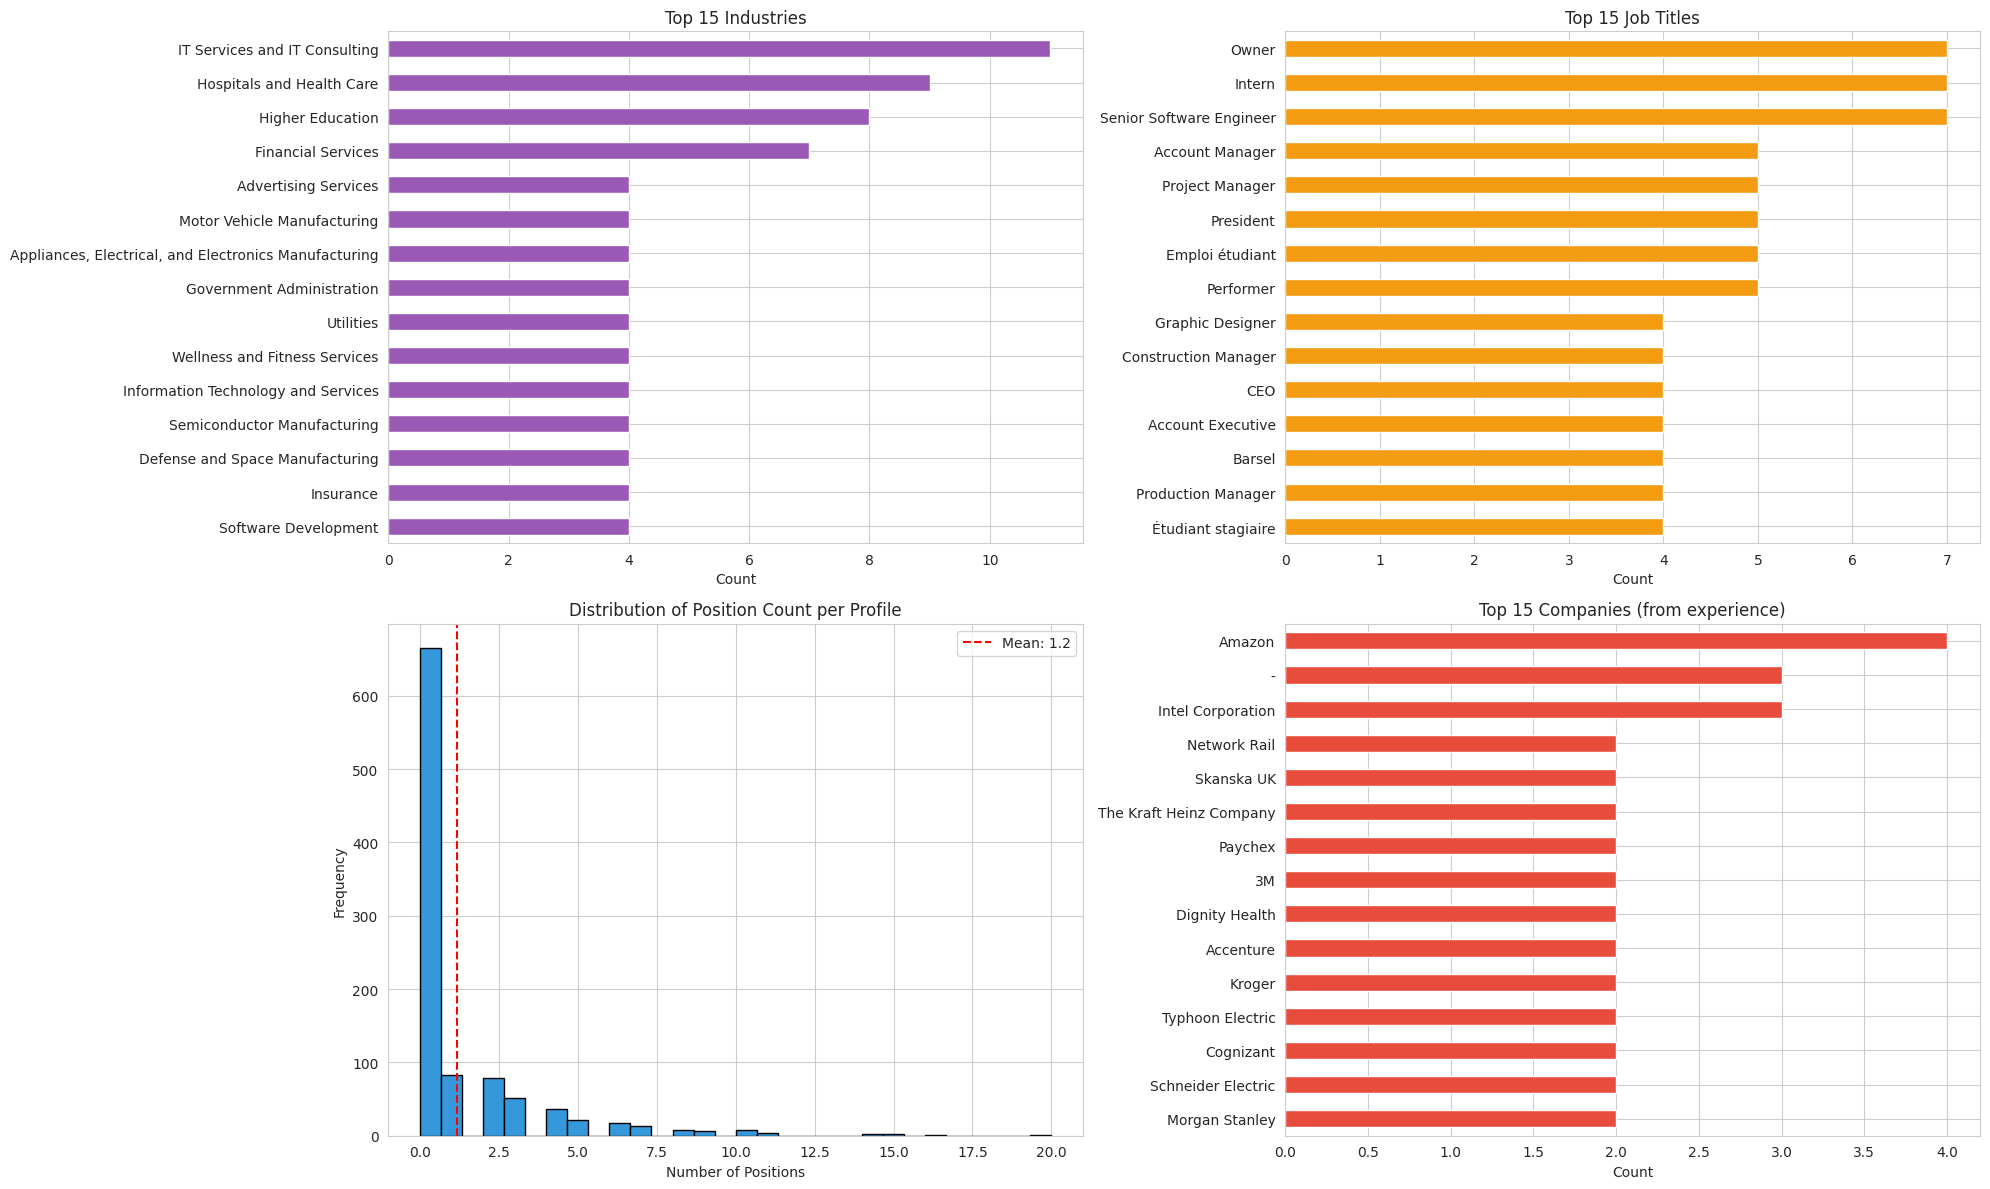


✓ Experience analysis complete


In [9]:
print("EXPERIENCE ANALYSIS")
print("="*80)

# Parse experience (JSON format)
def parse_experience(exp_json):
    if pd.isna(exp_json) or exp_json == '[]' or exp_json == '':
        return []
    try:
        exp_list = ast.literal_eval(exp_json)
        return exp_list if isinstance(exp_list, list) else []
    except:
        return []

# Extract experience data
all_companies = []
all_titles = []
all_industries = []
total_positions = []

for idx, row in df.iterrows():
    exp_list = parse_experience(row['experience'])
    position_count = 0
    
    for exp in exp_list:
        if isinstance(exp, dict):
            if 'company' in exp and exp['company']:
                all_companies.append(exp['company'])
            if 'industry' in exp and exp['industry']:
                all_industries.append(exp['industry'])
            if 'positions' in exp and isinstance(exp['positions'], list):
                position_count += len(exp['positions'])
                for pos in exp['positions']:
                    if isinstance(pos, dict) and 'title' in pos:
                        all_titles.append(pos['title'])
    
    total_positions.append(position_count)

df['total_positions'] = total_positions

print(f"Total experience records parsed: {len(all_companies)}")
print(f"Total job titles extracted: {len(all_titles)}")
print(f"Profiles with experience data: {df['experience'].notna().sum()} ({df['experience'].notna().mean()*100:.1f}%)")

# Position count statistics
print("\nPosition Count Statistics:")
print(f"  Mean positions per profile: {df['total_positions'].mean():.2f}")
print(f"  Median positions: {df['total_positions'].median():.0f}")
print(f"  Max positions: {df['total_positions'].max():.0f}")

# Industry distribution
industry_counts = Counter(all_industries)
print("\n" + "="*80)
print("TOP 20 INDUSTRIES")
print("="*80)
for i, (industry, count) in enumerate(industry_counts.most_common(20), 1):
    print(f"{i:2d}. {industry[:60]:60s}: {count:3d}")

# Job titles
title_counts = Counter(all_titles)
print("\n" + "="*80)
print("TOP 30 JOB TITLES (from experience)")
print("="*80)
for i, (title, count) in enumerate(title_counts.most_common(30), 1):
    print(f"{i:2d}. {title[:70]:70s}: {count:3d}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Top industries
top_industries = pd.Series(dict(industry_counts.most_common(15)))
top_industries.plot(kind='barh', ax=axes[0, 0], color='#9b59b6')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Top 15 Industries')
axes[0, 0].invert_yaxis()

# Top job titles
top_titles = pd.Series(dict(title_counts.most_common(15)))
top_titles.plot(kind='barh', ax=axes[0, 1], color='#f39c12')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Top 15 Job Titles')
axes[0, 1].invert_yaxis()

# Position count distribution
axes[1, 0].hist(df['total_positions'], bins=30, color='#3498db', edgecolor='black')
axes[1, 0].set_xlabel('Number of Positions')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Position Count per Profile')
axes[1, 0].axvline(df['total_positions'].mean(), color='red', linestyle='--', label=f'Mean: {df["total_positions"].mean():.1f}')
axes[1, 0].legend()

# Top companies
company_counts = Counter(all_companies)
top_companies = pd.Series(dict(company_counts.most_common(15)))
top_companies.plot(kind='barh', ax=axes[1, 1], color='#e74c3c')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Top 15 Companies (from experience)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(viz_dir / '05_experience_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Experience analysis complete")

---
## Step 8: Skills Extraction (CRITICAL - Inferred from Positions & Experience)

SKILLS ANALYSIS (Inferred from Titles & Industries)
Inferring skills from job titles and positions...

Inferred Skills Distribution:
  Total skill occurrences: 20000
  Unique skills: 20
  Mean skills per profile: 20.00
  Median skills per profile: 20

Skill Frequency:
  Consulting               : 1000 (100.0%)
  IT                       : 1000 (100.0%)
  Legal                    : 1000 (100.0%)
  Communication            : 1000 (100.0%)
  Software Development     : 1000 (100.0%)
  Operations               : 1000 (100.0%)
  Leadership               : 1000 (100.0%)
  Python                   : 1000 (100.0%)
  Project Management       : 1000 (100.0%)
  Design                   : 1000 (100.0%)
  Healthcare               : 1000 (100.0%)
  Marketing                : 1000 (100.0%)
  Sales                    : 1000 (100.0%)
  Engineering              : 1000 (100.0%)
  HR                       : 1000 (100.0%)
  Research                 : 1000 (100.0%)
  Customer Service         : 1000 (100.0%)


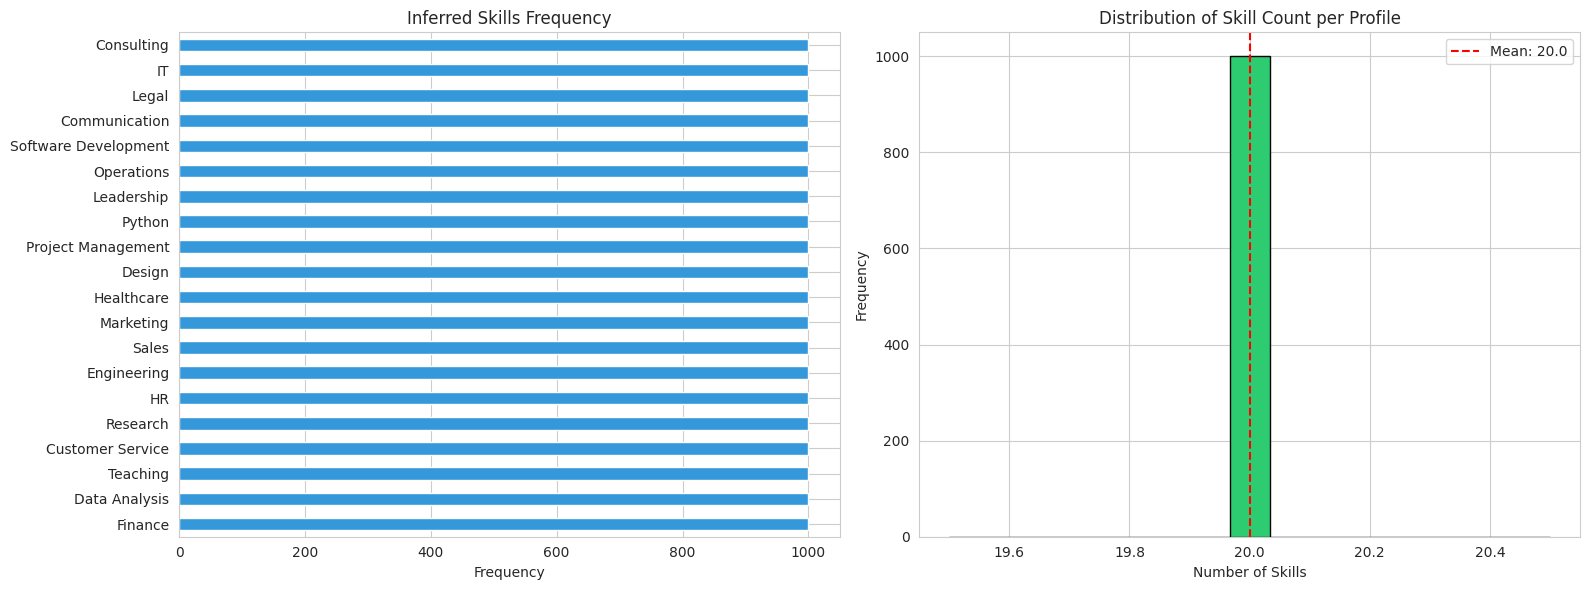


✓ Skills analysis complete


In [10]:
print("SKILLS ANALYSIS (Inferred from Titles & Industries)")
print("="*80)

# Note: This dataset doesn't have explicit skills field
# We'll infer skills from job titles and industries

SKILL_KEYWORDS = {
    'Python': ['python', 'data scientist', 'machine learning', 'ml engineer'],
    'Data Analysis': ['data analyst', 'analyst', 'analytics', 'data analysis'],
    'Project Management': ['project manager', 'program manager', 'pmo', 'project management'],
    'Leadership': ['director', 'manager', 'head', 'lead', 'chief', 'vp', 'president'],
    'Marketing': ['marketing', 'brand', 'digital marketing', 'social media'],
    'Sales': ['sales', 'business development', 'account manager'],
    'Software Development': ['software', 'developer', 'engineer', 'programming'],
    'Communication': ['communication', 'public relations', 'pr', 'content'],
    'Finance': ['finance', 'financial', 'accounting', 'accountant'],
    'Design': ['designer', 'design', 'ux', 'ui', 'creative'],
    'Research': ['research', 'scientist', 'researcher'],
    'Consulting': ['consultant', 'consulting', 'advisor'],
    'Teaching': ['teacher', 'professor', 'instructor', 'educator'],
    'HR': ['human resources', 'hr', 'recruiting', 'talent'],
    'Engineering': ['engineer', 'engineering'],
    'Healthcare': ['doctor', 'nurse', 'medical', 'healthcare'],
    'Legal': ['lawyer', 'attorney', 'legal', 'paralegal'],
    'Operations': ['operations', 'logistics', 'supply chain'],
    'IT': ['it', 'information technology', 'systems', 'network'],
    'Customer Service': ['customer service', 'customer support', 'client relations']
}

def infer_skills(row):
    skills = set()
    
    # Check position
    position = str(row['position']).lower() if pd.notna(row['position']) else ''
    
    # Check experience titles
    exp_titles = ' '.join(all_titles).lower()
    
    combined_text = position + ' ' + exp_titles
    
    for skill, keywords in SKILL_KEYWORDS.items():
        if any(keyword in combined_text for keyword in keywords):
            skills.add(skill)
    
    return list(skills)

# Infer skills for each profile
print("Inferring skills from job titles and positions...")
df['inferred_skills'] = df.apply(infer_skills, axis=1)
df['skill_count'] = df['inferred_skills'].apply(len)

# Count skill occurrences
all_inferred_skills = []
for skills in df['inferred_skills']:
    all_inferred_skills.extend(skills)

skill_frequency = Counter(all_inferred_skills)

print("\nInferred Skills Distribution:")
print(f"  Total skill occurrences: {len(all_inferred_skills)}")
print(f"  Unique skills: {len(skill_frequency)}")
print(f"  Mean skills per profile: {df['skill_count'].mean():.2f}")
print(f"  Median skills per profile: {df['skill_count'].median():.0f}")

print("\nSkill Frequency:")
for skill, count in skill_frequency.most_common():
    print(f"  {skill:25s}: {count:4d} ({count/len(df)*100:5.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Skill frequency
skill_series = pd.Series(dict(skill_frequency.most_common()))
skill_series.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Inferred Skills Frequency')
axes[0].invert_yaxis()

# Skill count distribution
axes[1].hist(df['skill_count'], bins=15, color='#2ecc71', edgecolor='black')
axes[1].set_xlabel('Number of Skills')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Skill Count per Profile')
axes[1].axvline(df['skill_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["skill_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(viz_dir / '06_skills_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Skills analysis complete")

---
## Step 9: Languages Analysis

LANGUAGES ANALYSIS
Profiles with language data: 255 (25.5%)
Total languages: 607
Mean languages per profile: 0.61

Top 20 Languages:
 1. English                       : 175
 2. Spanish                       :  39
 3. French                        :  29
 4. Hindi                         :  29
 5. Arabic                        :  20
 6. German                        :  19
 7. Russian                       :  13
 8. Inglés                        :  11
 9. Anglais                       :   9
10. Español                       :   8
11. Malayalam                     :   8
12. Swedish                       :   8
13. Italiano                      :   7
14. Italian                       :   7
15. Français                      :   7
16. Engels                        :   7
17. Englisch                      :   7
18. Dutch                         :   6
19. Tamil                         :   6
20. Duits                         :   6


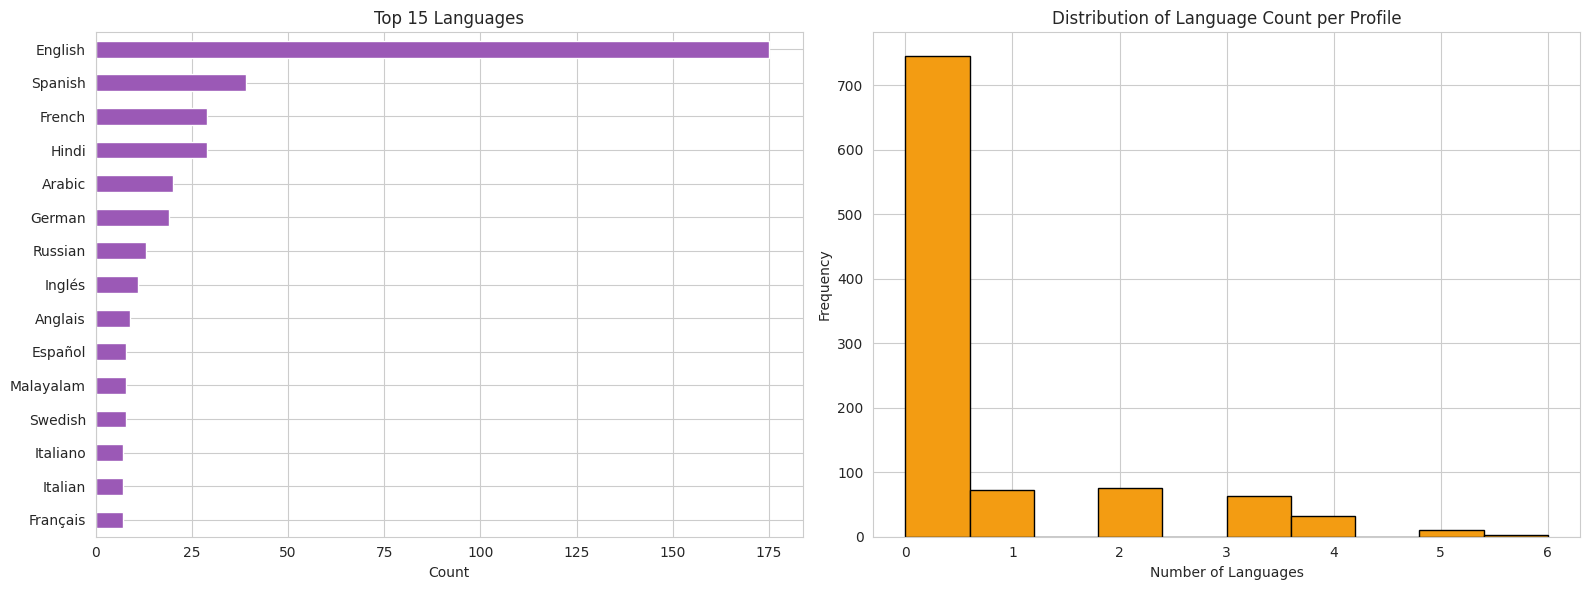


✓ Languages analysis complete


In [11]:
print("LANGUAGES ANALYSIS")
print("="*80)

# Parse languages
def parse_languages(lang_json):
    if pd.isna(lang_json) or lang_json == '[]' or lang_json == '':
        return []
    try:
        lang_list = ast.literal_eval(lang_json)
        return lang_list if isinstance(lang_list, list) else []
    except:
        return []

# Extract all languages
all_languages = []
language_counts_per_profile = []

for _, row in df.iterrows():
    lang_list = parse_languages(row['languages'])
    language_counts_per_profile.append(len(lang_list))
    for lang in lang_list:
        if isinstance(lang, dict) and 'title' in lang:
            all_languages.append(lang['title'])

df['language_count'] = language_counts_per_profile

print(f"Profiles with language data: {df['languages'].notna().sum()} ({df['languages'].notna().mean()*100:.1f}%)")
print(f"Total languages: {len(all_languages)}")
print(f"Mean languages per profile: {df['language_count'].mean():.2f}")

# Language distribution
lang_frequency = Counter(all_languages)
print("\nTop 20 Languages:")
for i, (lang, count) in enumerate(lang_frequency.most_common(20), 1):
    print(f"{i:2d}. {lang:30s}: {count:3d}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top languages
top_langs = pd.Series(dict(lang_frequency.most_common(15)))
top_langs.plot(kind='barh', ax=axes[0], color='#9b59b6')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Languages')
axes[0].invert_yaxis()

# Language count distribution
axes[1].hist(df['language_count'], bins=10, color='#f39c12', edgecolor='black')
axes[1].set_xlabel('Number of Languages')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Language Count per Profile')

plt.tight_layout()
plt.savefig(viz_dir / '07_languages_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Languages analysis complete")

---
## Step 10: Certifications Analysis

In [12]:
print("CERTIFICATIONS ANALYSIS")
print("="*80)

# Parse certifications
def parse_certifications(cert_json):
    if pd.isna(cert_json) or cert_json == '[]' or cert_json == '':
        return []
    try:
        cert_list = ast.literal_eval(cert_json)
        return cert_list if isinstance(cert_list, list) else []
    except:
        return []

# Extract certifications
all_certifications = []
cert_counts_per_profile = []

for _, row in df.iterrows():
    cert_list = parse_certifications(row['certifications'])
    cert_counts_per_profile.append(len(cert_list))
    for cert in cert_list:
        if isinstance(cert, dict) and 'title' in cert:
            all_certifications.append(cert['title'])

df['certification_count'] = cert_counts_per_profile

print(f"Profiles with certifications: {df['certifications'].notna().sum()} ({df['certifications'].notna().mean()*100:.1f}%)")
print(f"Total certifications: {len(all_certifications)}")
print(f"Mean certifications per profile: {df['certification_count'].mean():.2f}")

# Certification distribution
cert_frequency = Counter(all_certifications)
print("\nTop 20 Certifications:")
for i, (cert, count) in enumerate(cert_frequency.most_common(20), 1):
    print(f"{i:2d}. {cert[:70]:70s}: {count:2d}")

print("\n✓ Certifications analysis complete")

CERTIFICATIONS ANALYSIS
Profiles with certifications: 184 (18.4%)
Total certifications: 653
Mean certifications per profile: 0.65

Top 20 Certifications:
 1. Microsoft Certified: Azure Fundamentals                               :  4
 2. Microsoft Certified: Azure Administrator Associate                    :  4
 3. IBM Power Systems Infrastructure Sales Foundation V2                  :  2
 4. All Flash Storage Foundations V2                                      :  2
 5. Virtual Open Day                                                      :  2
 6. Registered Engineer                                                   :  2
 7. Registered Nurse                                                      :  2
 8. ITIL® Foundation Certificate in IT Service Management                 :  2
 9. ONEx Agile Fundamentals                                               :  2
10. Pharmacist                                                            :  2
11. Intelligent Enterprise 2021 - Source to Pay         

---
## Step 11: Profile Completeness Score

PROFILE COMPLETENESS ANALYSIS
Completeness Score Statistics:
  Mean: 63.56%
  Median: 66.67%
  Min: 25.00%
  Max: 100.00%

Completeness Categories:
completeness_category
Low         8
Medium    402
High      590
Name: count, dtype: int64


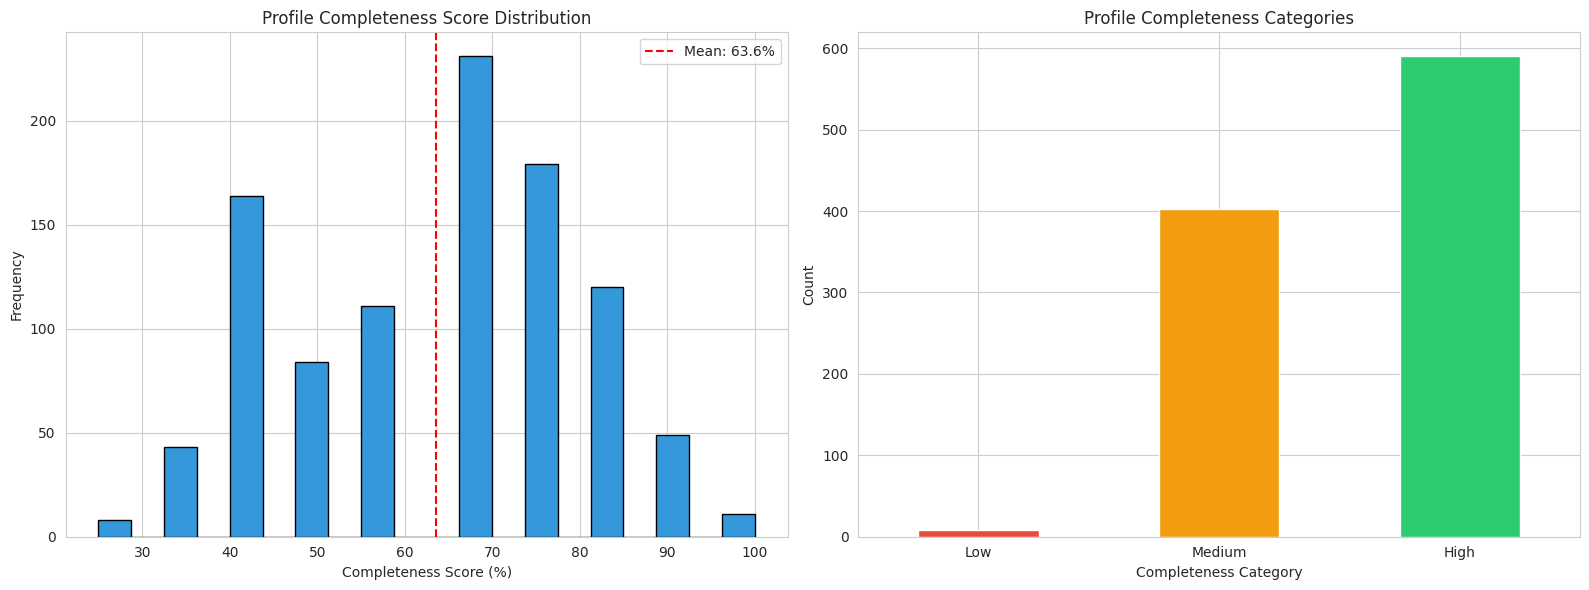


✓ Completeness analysis complete


In [13]:
print("PROFILE COMPLETENESS ANALYSIS")
print("="*80)

# Calculate completeness score
def calculate_completeness(row):
    score = 0
    max_score = 12
    
    # Basic info (4 points)
    if pd.notna(row['name']) and row['name'] != '': score += 1
    if pd.notna(row['city']) and row['city'] != '': score += 1
    if pd.notna(row['position']) and row['position'] != '': score += 1
    if pd.notna(row['about']) and row['about'] != '': score += 1
    
    # Experience (2 points)
    if pd.notna(row['experience']) and row['experience'] != '[]': score += 1
    if row['total_positions'] > 0: score += 1
    
    # Education (2 points)
    if pd.notna(row['educations_details']) and row['educations_details'] != '[]': score += 1
    if pd.notna(row['education']) and row['education'] != '': score += 1
    
    # Additional info (4 points)
    if pd.notna(row['languages']) and row['languages'] != '[]': score += 1
    if pd.notna(row['certifications']) and row['certifications'] != '[]': score += 1
    if pd.notna(row['volunteer_experience']) and row['volunteer_experience'] != '[]': score += 1
    if row['skill_count'] > 0: score += 1
    
    return (score / max_score) * 100

df['completeness_score'] = df.apply(calculate_completeness, axis=1)

print("Completeness Score Statistics:")
print(f"  Mean: {df['completeness_score'].mean():.2f}%")
print(f"  Median: {df['completeness_score'].median():.2f}%")
print(f"  Min: {df['completeness_score'].min():.2f}%")
print(f"  Max: {df['completeness_score'].max():.2f}%")

# Completeness categories
df['completeness_category'] = pd.cut(df['completeness_score'], 
                                       bins=[0, 33, 66, 100], 
                                       labels=['Low', 'Medium', 'High'])

print("\nCompleteness Categories:")
print(df['completeness_category'].value_counts().sort_index())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Completeness distribution
axes[0].hist(df['completeness_score'], bins=20, color='#3498db', edgecolor='black')
axes[0].set_xlabel('Completeness Score (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Profile Completeness Score Distribution')
axes[0].axvline(df['completeness_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["completeness_score"].mean():.1f}%')
axes[0].legend()

# Completeness categories
df['completeness_category'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_xlabel('Completeness Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Profile Completeness Categories')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(viz_dir / '08_completeness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Completeness analysis complete")

---
## Step 12: Summary Statistics & Export

In [14]:
print("FINAL SUMMARY STATISTICS")
print("="*80)

summary_stats = {
    'total_profiles': len(df),
    'countries': df['country_code'].nunique(),
    'cities': df['city'].nunique(),
    'unique_positions': df['position'].nunique(),
    'unique_companies': df['current_company:name'].nunique(),
    'profiles_with_education': df['educations_details'].notna().sum(),
    'profiles_with_experience': df['experience'].notna().sum(),
    'profiles_with_languages': df['languages'].notna().sum(),
    'profiles_with_certifications': df['certifications'].notna().sum(),
    'total_degrees': len(all_degrees),
    'unique_degrees': len(degree_counts),
    'unique_fields_of_study': len(field_counts),
    'total_job_titles': len(all_titles),
    'unique_industries': len(industry_counts),
    'total_inferred_skills': len(all_inferred_skills),
    'unique_skills': len(skill_frequency),
    'mean_completeness_score': float(df['completeness_score'].mean()),
    'mean_positions_per_profile': float(df['total_positions'].mean()),
    'mean_skills_per_profile': float(df['skill_count'].mean()),
    'mean_languages_per_profile': float(df['language_count'].mean())
}

print("\nDataset Overview:")
for key, value in summary_stats.items():
    print(f"  {key.replace('_', ' ').title():35s}: {value:>10}")

# Save summary to JSON
with open(output_dir / 'summary_statistics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(f"\n✓ Summary statistics saved to {output_dir / 'summary_statistics.json'}")

# Save processed dataframe
df_export = df[['id', 'name', 'city', 'country_code', 'region', 'position', 
                'current_company:name', 'job_level', 'inferred_skills', 'skill_count',
                'total_positions', 'language_count', 'certification_count', 
                'completeness_score', 'completeness_category']].copy()

df_export.to_csv(output_dir / 'linkedin_profiles_processed.csv', index=False)
print(f"✓ Processed data saved to {output_dir / 'linkedin_profiles_processed.csv'}")

print("\n" + "="*80)
print("EDA COMPLETE")
print("="*80)
print(f"📊 Visualizations saved to: {viz_dir}")
print(f"💾 Processed data saved to: {output_dir}")
print(f"\nTotal visualizations: 8 PNG files")
print("\nNext step: Review features for Wide&Deep recommender training")

FINAL SUMMARY STATISTICS

Dataset Overview:
  Total Profiles                     :       1000
  Countries                          :         82
  Cities                             :        671
  Unique Positions                   :        925
  Unique Companies                   :        813
  Profiles With Education            :        682
  Profiles With Experience           :        906
  Profiles With Languages            :        255
  Profiles With Certifications       :        184
  Total Degrees                      :          0
  Unique Degrees                     :          0
  Unique Fields Of Study             :          0
  Total Job Titles                   :       1170
  Unique Industries                  :         86
  Total Inferred Skills              :      20000
  Unique Skills                      :         20
  Mean Completeness Score            : 63.55833333333333
  Mean Positions Per Profile         :       1.19
  Mean Skills Per Profile            :       20.0

TypeError: Object of type int64 is not JSON serializable